In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yasasashinsana","key":"6b8e9a4ec477707b1400d364996ac4a8"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dogs-vs-cats
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

100% 812M/812M [00:03<00:00, 235MB/s]



In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/content/train" # Unzip  dataset  path

In [23]:
#  Data Cleaning & Integrity Check ---

valid_extensions = ['.jpg', '.jpeg', '.png']
corrupted_count = 0
valid_count = 0

print("Checking Dataset Integrity... (This might take a minute)")

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)

    # 1. Check for valid file extensions (remove irrelevant files)
    if not any(file_path.lower().endswith(ext) for ext in valid_extensions):
        os.remove(file_path)
        corrupted_count += 1
        continue

    # 2. Check if the image is corrupted using OpenCV
    img = cv2.imread(file_path)
    if img is None:
        os.remove(file_path) # Remove unreadable images
        corrupted_count += 1
    else:
        valid_count += 1

print(f"Cleaned! Valid Images: {valid_count} | Corrupted/Removed: {corrupted_count}")


Checking Dataset Integrity... (This might take a minute)
Cleaned! Valid Images: 25000 | Corrupted/Removed: 0


In [7]:
#  Label Encoding & Class Distribution ---
image_paths = []
labels = []

# Extract label from filename (cat = 0, dog = 1) without plotting charts
for file in os.listdir(dataset_path):
    if file.endswith('.jpg'):
        image_paths.append(os.path.join(dataset_path, file))
        if 'cat' in file:
            labels.append(0)
        elif 'dog' in file:
            labels.append(1)

print(f"Labels Encoded. Total paths found: {len(image_paths)}")
print(f"Cats: {labels.count(0)} | Dogs: {labels.count(1)}")


Labels Encoded. Total paths found: 25000
Cats: 12500 | Dogs: 12500


In [8]:
IMG_SIZE = 128
X_resized = []
y_labels = []

# Resize images (processing up to 2000 images to prevent RAM crashes)
for i in range(min(2000, len(image_paths))):
    img = cv2.imread(image_paths[i])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
        resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Standardize to 128x128
        X_resized.append(resized_img)
        y_labels.append(labels[i])

# Convert lists to NumPy Arrays (Standard format for ML models)
X_resized = np.array(X_resized)
y_labels = np.array(y_labels)
print(f"Resized Data Shape: {X_resized.shape}")

Resized Data Shape: (2000, 128, 128, 3)


In [9]:
#Pixel Normalization ---
X_normalized = X_resized / 255.0

print(f"Normalization Complete. Max value AFTER normalization: {X_normalized.max()}")

Normalization Complete. Max value AFTER normalization: 1.0


In [10]:
#  Color Channel Analysis ---
rgb_features = []

# Calculate mean intensity for Red, Green, and Blue channels for each image
for img in X_normalized:
    r_mean = np.mean(img[:, :, 0])
    g_mean = np.mean(img[:, :, 1])
    b_mean = np.mean(img[:, :, 2])
    rgb_features.append([r_mean, g_mean, b_mean])

# Convert list to NumPy Array
rgb_features = np.array(rgb_features)
print(f"RGB Features extracted shape: {rgb_features.shape}")

RGB Features extracted shape: (2000, 3)


In [25]:
# Geometric Transformations (Pipeline Version) ---
print("Applying Geometric Augmentations (Flip & Rotate)...")

augmented_images = []
augmented_labels = []

# To prevent RAM crashes, apply augmentation to a safe slice (e.g., first 1000 images)
for i in range(min(1000, len(X_normalized))):
    # Convert back to 0-255 uint8 format for OpenCV operations, then normalize back
    img_uint8 = (X_normalized[i] * 255).astype(np.uint8)
    label = y_labels[i]

    # 1. Horizontal Flip
    flipped_img = cv2.flip(img_uint8, 1)
    augmented_images.append(flipped_img / 255.0)
    augmented_labels.append(label)

    # 2. Rotate each image by 45 degrees
    center = (img_uint8.shape[1]//2, img_uint8.shape[0]//2)
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
    rotated_img = cv2.warpAffine(img_uint8, rotation_matrix, (img_uint8.shape[1], img_uint8.shape[0]))
    augmented_images.append(rotated_img / 255.0)
    augmented_labels.append(label)

print(f"Successfully generated {len(augmented_images)} new augmented images!")

# Concatenate the newly created images with the original normalized dataset to create the final pipeline arrays
X_final_pipeline = np.concatenate((X_normalized, np.array(augmented_images)), axis=0)
y_final_pipeline = np.concatenate((y_labels, np.array(augmented_labels)), axis=0)

print(f"Final Dataset Size after Augmentation (X): {X_final_pipeline.shape}")
print(f"Final Labels Size after Augmentation (y): {y_final_pipeline.shape}")

Applying Geometric Augmentations (Flip & Rotate)...
Successfully generated 2000 new augmented images!
Final Dataset Size after Augmentation (X): (4000, 128, 128, 3)
Final Labels Size after Augmentation (y): (4000,)


In [12]:
shifted_images = []
shifted_labels = []

# Loop through all normalized images to apply shift transformation
for i in range(len(X_normalized)):
    # Convert back to 0-255 uint8 format for OpenCV operations
    img_uint8 = (X_normalized[i] * 255).astype(np.uint8)
    label = y_labels[i]

    rows, cols, _ = img_uint8.shape
    # Shift matrix: 30 pixels right and down (Translation)
    shift_matrix = np.float32([[1, 0, 30], [0, 1, 30]])
    shifted_img = cv2.warpAffine(img_uint8, shift_matrix, (cols, rows))

    # Normalize back to 0.0 - 1.0 and append
    shifted_images.append(shifted_img / 255.0)
    shifted_labels.append(label)

# Convert lists to NumPy Arrays
X_shifted_array = np.array(shifted_images)
y_shifted_array = np.array(shifted_labels)

print(f"Shifted Data Shape: {X_shifted_array.shape}")

Shifted Data Shape: (2000, 128, 128, 3)


Cats in current batch: 973
Dogs in current batch: 1027
Average Cat Image calculated successfully! Shape: (128, 128)
Average Dog Image calculated successfully! Shape: (128, 128)


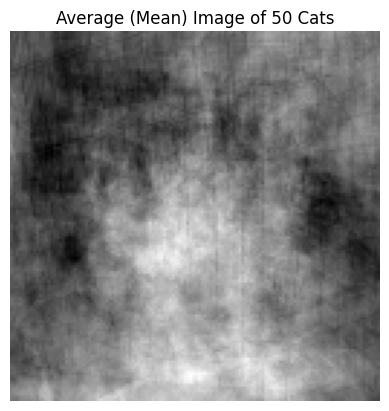

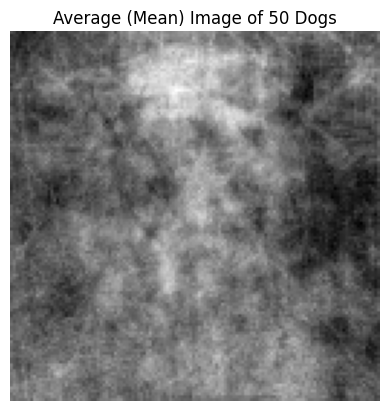

In [22]:
#  Average Image Analysis ---
print("Cats in current batch:", (y_labels == 0).sum())
print("Dogs in current batch:", (y_labels == 1).sum())

# Filter cat images (label 0) from the already processed dataset
cat_indices = [i for i, label in enumerate(y_labels) if label == 0]
cat_images_pipeline = X_normalized[cat_indices[:50]] # Take up to 50 cat images

if len(cat_images_pipeline) > 0:
    cat_gray_list = []
    for img in cat_images_pipeline:
        # Convert RGB to Grayscale to match the original analysis logic
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        cat_gray_list.append(gray)

    # Calculate mean image
    cat_images_array = np.array(cat_gray_list)
    mean_cat_image = np.mean(cat_images_array, axis=0)

    print(f"Average Cat Image calculated successfully! Shape: {mean_cat_image.shape}")
else:
    print("No cat images found in the current batch.")

# Filter dog images (label 1) from the already processed dataset
dog_indices = [i for i, label in enumerate(y_labels) if label == 1]
dog_images_pipeline = X_normalized[dog_indices[:50]] # Take up to 50 dog images

if len(dog_images_pipeline) > 0:
    dog_gray_list = []
    for img in dog_images_pipeline:
        # Convert RGB to Grayscale to match the original analysis logic
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        dog_gray_list.append(gray)

    # Calculate mean image
    dog_images_array = np.array(dog_gray_list)
    mean_dog_image = np.mean(dog_images_array, axis=0)

    print(f"Average Dog Image calculated successfully! Shape: {mean_dog_image.shape}")
else:
    print("No dog images found in the current batch.")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# --- Show Average Cat Image ---
plt.imshow(mean_cat_image, cmap='gray')
plt.title('Average (Mean) Image of 50 Cats')
plt.axis('off')
plt.show()

# --- Show Average Dog Image ---
plt.imshow(mean_dog_image, cmap='gray')
plt.title('Average (Mean) Image of 50 Dogs')
plt.axis('off')
plt.show()


 PIPELINE EXECUTION SUMMARY 
-> Total Processed & Augmented Images (X): (4000, 128, 128, 3)
-> Total Corresponding Labels (y): (4000,)
-> Data Type / Format: float64
-> Pixel Value Range: Min = 0.0 | Max = 1.0


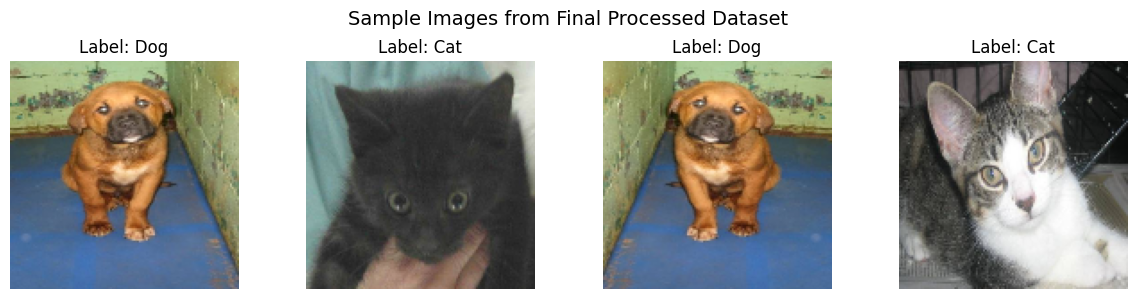

In [24]:
# FINAL PIPELINE OUTPUT & SUMMARY DISPLAY

import matplotlib.pyplot as plt

print("\n" + "="*40)
print(" PIPELINE EXECUTION SUMMARY ")
print("="*40)
print(f"-> Total Processed & Augmented Images (X): {X_final_pipeline.shape}")
print(f"-> Total Corresponding Labels (y): {y_final_pipeline.shape}")
print(f"-> Data Type / Format: {X_final_pipeline.dtype}")
print(f"-> Pixel Value Range: Min = {X_final_pipeline.min():.1f} | Max = {X_final_pipeline.max():.1f}")
print("="*40)

# Display a few sample images from the final pipeline dataset to show off at the end!
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    # Pick a few random images from the final dataset
    sample_idx = i * 1000  # Spread out samples
    if sample_idx < len(X_final_pipeline):
        ax.imshow(X_final_pipeline[sample_idx])
        ax.set_title(f"Label: {'Dog' if y_final_pipeline[sample_idx] == 1 else 'Cat'}")
        ax.axis('off')

plt.suptitle("Sample Images from Final Processed Dataset", fontsize=14)
plt.tight_layout()
plt.show()